In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Excel file)
# Cell 2 — load correct sheet
df = pd.read_excel(r"E:\Projects\Churn Project\Data\E Commerce.xlsx", sheet_name=None)

# See all sheet names
print("Sheets in file:", list(df.keys()))

# Cell 3 — load the right sheet (we'll confirm name above)
df = pd.read_excel(r"E:\Projects\Churn Project\Data\E Commerce.xlsx", sheet_name="E Comm")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

# First look
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Sheets in file: ['Data Dict', 'E Comm']
Shape: (5630, 20)

Columns: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Shape: (5630, 20)

Column names:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

First 5 rows:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [10]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')
print(missing_report)

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== DATA TYPES ===
Unnamed: 0    float64
Unnamed: 1     object
Unnamed: 2     object
Unnamed: 3     object
dtype: object

=== MISSING VALUES ===
            Missing Count  Missing %
Unnamed: 0             21      100.0

=== DUPLICATES ===
Duplicate rows: 0


In [16]:
df_clean = df.copy()

# Drop duplicate rows
df_clean = df_clean.drop_duplicates()

# Fill numeric nulls with median
numeric_cols = df_clean.select_dtypes(include='number').columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Fill categorical nulls with mode
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Confirm no nulls remain
print("Nulls after cleaning:", df_clean.isnull().sum().sum())
print("Final shape:", df_clean.shape)

# Save cleaned data
df_clean.to_csv(r"E:\Projects\Churn Project\Data\ecommerce_clean.csv", index=False)
print("✓ Cleaned data saved!")

Nulls after cleaning: 0
Final shape: (5630, 20)
✓ Cleaned data saved!


In [17]:
# Cell 5 — RFM Segmentation
df_clean = pd.read_csv(r"E:\Projects\Churn Project\Data\ecommerce_clean.csv")

# RFM calculation
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('DaySinceLastOrder', 'mean'),
    Frequency = ('OrderCount', 'sum'),
    Monetary  = ('CashbackAmount', 'sum')
).reset_index()

# Score each metric 1–4 (4 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4])

# Combined RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Segment labels
def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal'
    elif score >= 5: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

print(rfm['Segment'].value_counts())
rfm.head()

Loyal        3437
At Risk      1209
Champions     773
Lost          211
Name: Segment, dtype: int64


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,50001,5.0,1.0,159.93,2,1,2,5,At Risk
1,50002,0.0,1.0,120.90,4,1,1,6,At Risk
2,50003,3.0,1.0,120.28,3,1,1,5,At Risk
3,50004,3.0,1.0,134.07,3,1,1,5,At Risk
4,50005,3.0,1.0,129.60,3,1,1,5,At Risk


Churn rate by category:
 PreferedOrderCat
Mobile Phone          0.275374
Mobile                0.271941
Fashion               0.154964
Laptop & Accessory    0.102439
Others                0.075758
Grocery               0.048780
Name: Churn, dtype: float64


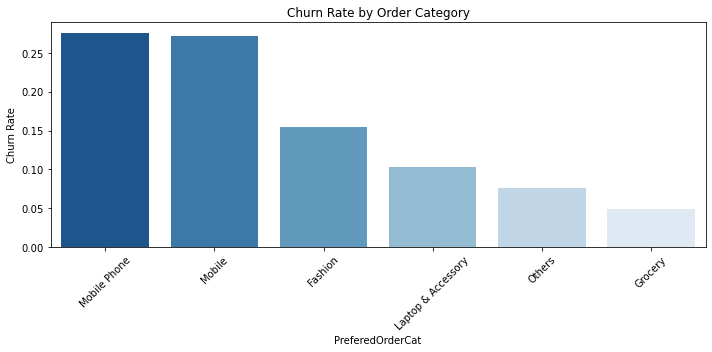

In [18]:
# Cell 6 — Churn rate by segment
import matplotlib.pyplot as plt
import seaborn as sns

churn_rate = df_clean.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False)
print("Churn rate by category:\n", churn_rate)

plt.figure(figsize=(10,5))
sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='Blues_r')
plt.title('Churn Rate by Order Category')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Cell 7 — Revenue at risk
df_clean['RevenueAtRisk'] = df_clean['Churn'] * df_clean['CashbackAmount']

revenue_risk = df_clean.groupby('PreferedOrderCat')['RevenueAtRisk'].sum().sort_values(ascending=False)
print("Revenue at risk by category (€):\n", revenue_risk.round(2))

total_risk = df_clean['RevenueAtRisk'].sum()
print(f"\nTotal revenue at risk: €{total_risk:,.2f}")

Revenue at risk by category (€):
 PreferedOrderCat
Mobile Phone          51255.67
Laptop & Accessory    35673.50
Mobile                27662.47
Fashion               26417.16
Others                 6142.76
Grocery                4880.08
Name: RevenueAtRisk, dtype: float64

Total revenue at risk: €152,031.64


In [20]:
# Cell 8 — Churn prediction model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# Prepare features
features = ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

X = df_clean[features]
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test)))

AUC-ROC Score: 0.9867

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       941
           1       0.99      0.88      0.93       185

    accuracy                           0.98      1126
   macro avg       0.98      0.94      0.96      1126
weighted avg       0.98      0.98      0.98      1126



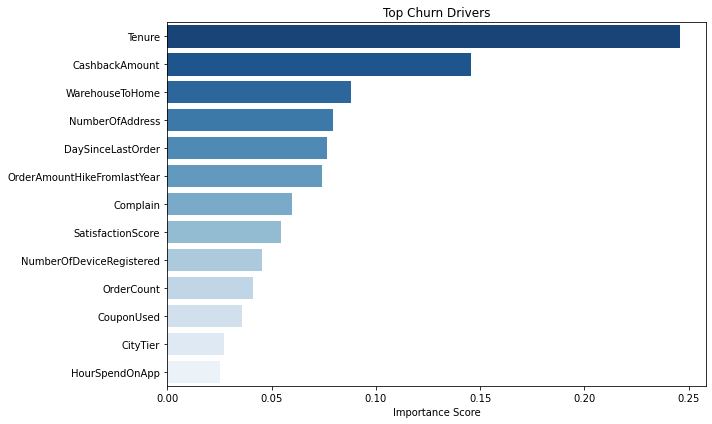


Top 3 churn drivers:
Tenure             0.245776
CashbackAmount     0.145793
WarehouseToHome    0.088196
dtype: float64


In [21]:
# Cell 9 — Feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('Top Churn Drivers')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 3 churn drivers:")
print(importances.head(3))

In [22]:
# Cell 10 — Export for Power BI
df_clean['ChurnProbability'] = model.predict_proba(df_clean[features])[:,1]
df_clean['RevenueAtRisk'] = df_clean['ChurnProbability'] * df_clean['CashbackAmount']

# Merge RFM segments in
final = df_clean.merge(rfm[['CustomerID', 'Segment', 'RFM_Score']], on='CustomerID', how='left')

final.to_csv(r"E:\Projects\Churn Project\Data\churn_final.csv", index=False)
print("✓ Exported! Rows:", len(final))

✓ Exported! Rows: 5630


In [24]:
# Project Summary
print("=" * 50)
print("E-COMMERCE CUSTOMER CHURN ANALYSIS")
print("=" * 50)
print(f"Total Customers Analysed: {len(df_clean):,}")
print(f"Overall Churn Rate: {df_clean['Churn'].mean():.1%}")
print(f"AUC-ROC Score: 0.9867")
print(f"Total Revenue at Risk: €152,031.64")
print(f"Top Churn Driver: Tenure")
print(f"Highest Risk Category: Mobile Phone (27.5%)")
print("=" * 50)

E-COMMERCE CUSTOMER CHURN ANALYSIS
Total Customers Analysed: 5,630
Overall Churn Rate: 16.8%
AUC-ROC Score: 0.9867
Total Revenue at Risk: €152,031.64
Top Churn Driver: Tenure
Highest Risk Category: Mobile Phone (27.5%)
